# Geometric Signals of Bleaching

## Introduction

In her 1988 paper, Sweetser proposes an explanation of semantic bleaching based on an abstraction related to the image-schematic topological structure of a word. For example, the usage of go in the tense Go-future relates to the abstract notion of moving from a present state to a future state. If you are going to do something, you will move from having not done it to having completed the task in the same way that you go down the block. I drew a connection between her work and Pavlick's paper titled _Most babies are little and most problems are huge: Compositional Entailment in Adjective-Nouns_. While Sweetser focuses mainly on an image-based explanation for semantic shifts, Pavlick considers a bottom-up approach where nouns have intrinsic, modifiable properties; a mock trial confers enough properties of trial, while a mock execution doesn't entail the specific, essential property of an execution. Taken together, I believe these theories suggest bleaching is geometrically identifiable: bleached words should show higher neighborhood turnover over time as they lose specific meaning and move towards topological abstraction.

To examine this, I used Hamilton's HistWords embeddings (William L. Hamilton, Jure Leskovec, and Dan Jurafsky. ACL 2016. Diachronic Word Embeddings Reveal Statistical Laws of Semantic Change). Specifically, I used the "All English (1800s-1990s)." I chose to use these embeddings for simplicity, but also for completeness.

In [1]:
import numpy as np
import pickle

def load_decade(decade, base_path):
    vectors = np.load(f'{base_path}/{decade}-w.npy')
    with open(f'{base_path}/{decade}-vocab.pkl', 'rb') as f:
        vocab = pickle.load(f)
    word_index = {word: idx for idx, word in enumerate(vocab)}
    return vectors, vocab, word_index
def get_vector(word, vectors, vocab):
    if word in vocab:
        return vectors[vocab[word]]
    return None

In [2]:
vectors, vocab, w2i = load_decade(1990, "./sgns")

I created several methods (implemented above) to load vectors by decade and specific words from each set of vectors. From here, I chose a few words to test the geometric signals on. For control words--which I expected to change very little--I chose oak, cathedral, elbow, and copper. None of the four words, with the slight exception of elbow, has a specific topological meaning. However, there are several subtleties in the secondary senses for each word: elbow used as a verb, cathedral in the context of travel books, and so on. The bleached words were chosen specifically for their topological meanings; Sweetser mentions all in her paper. Go and may are a central focus in her work, with pass and again also making appearances in case studies. This provides a theoretical ground truth for the direction of change.

In [3]:
decades = range(1800,2000,10)
base_path = "./sgns"

bleached = ["go", "may", "again", "pass", "awfully","wildly","insanely","abundantly","terribly","aggressively"]
control = ["oak","cathedral", "elbow", "copper","very"]

bleached_vectors = {word: {} for word in bleached}
control_vectors = {word: {} for word in control}

for decade in decades:
    vectors, vocab, w2i = load_decade(decade, base_path)
    for word in bleached:
        vec = get_vector(word, vectors, w2i)
        if vec is not None:
            bleached_vectors[word][decade] = vec
    for word in control:
        vec = get_vector(word, vectors, w2i)
        if vec is not None:
            control_vectors[word][decade] = vec


## Geometric Signals

I chose to use cosine similarity and Jaccard's index for my preliminary geometric signals. Cosine similarity was chosen to identify potential large-scale rotation in the vector space. Words with significantly changed meanings would shift more, while those with relatively stable meanings should remain in place. Jaccard's index was chosen to quantify the change in the k-nearest neighbors of a word; closer to 1 means less change, while closer to 0 indicates more. I considered using vector magnitude as a third signal, but realized that Hamilton's word embeddings are normalized, rendering the metric uninformative. Vector magnitude would provide a measure of relative intensity, which I would expect to decrease as words bleached.

In [4]:
def cosine_similarity(v1, v2):
    dot_product = np.dot(v1,v2)
    v1_mag = np.linalg.norm(v1)
    v2_mag = np.linalg.norm(v2)

    return dot_product/(v1_mag*v2_mag)

In [5]:
print(cosine_similarity(control_vectors["oak"][1900], control_vectors["oak"][1990]))
print(cosine_similarity(bleached_vectors["pass"][1900], bleached_vectors["pass"][1990]))

0.4520813125171673
0.5227764674768521


I was a little disappointed in the preliminary results of cosine similarity; the difference between the chosen control word and the chosen bleaching word--pass, which Sweetser flags as having changed in meaning--was almost negligible. I ran the same experiment with several other words that should not experience any change in meaning.

In [6]:
# if these are suspiciously similar the spaces are probably aligned
vectors_1900, _, w2i_1900 = load_decade(1900, base_path=base_path)
vectors_1990, _, w2i_1990 = load_decade(1990, base_path=base_path)

stable_anchors = ['the', 'and', 'of', 'is', 'was']
for word in stable_anchors:
    v1 = get_vector(word, vectors_1900, w2i_1900)
    v2 = get_vector(word, vectors_1990, w2i_1990)
    print(f"{word}: {cosine_similarity(v1, v2):.3f}")

the: 0.723
and: 0.265
of: 0.405
is: 0.434
was: 0.453


The inconsistencies in cosine similarity between such typical words suggests that cosine similarity is a blunt instrument, at least with these embeddings. I believe this is because cosine similarity does not reveal words whose meanings become diffuse, but maintain their general sense, and over-compensates for words that dramatically shift without actually losing specificity. Jaccard's index should fix this issue by directly comparing the overlap between similar words across decades.

Below is a graph of the cosine similarities for each chosen word across the duration of the embedding timeframe. There is not a clear trend between the bleaching or control candidates.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

bleached_colors = {
    'go': '#2196F3',
    'may': '#9C27B0',
    'again': '#00BCD4',
    'pass': '#3F51B5'
}

control_colors = {
    'oak': '#F44336',
    'cathedral': '#FF9800',
    'elbow': '#4CAF50',
    'copper': "#2B2625"
}

decades = [d for d, _ in cosine_results['go']]
plot_start = 10
plot_decades = decades[plot_start:]

bleached_avg = np.mean([[s for _, s in cosine_results[w]][plot_start:] for w in bleached], axis=0)
control_avg = np.mean([[s for _, s in cosine_results[w]][plot_start:] for w in control], axis=0)

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(plot_decades, bleached_avg, marker='o', label='bleached (avg)', color='steelblue', linewidth=2)
ax1.plot(plot_decades, control_avg, marker='o', label='control (avg)', color='coral', linewidth=2)

ax1.set_title('Average Cosine Similarity Across Decades')
ax1.set_xlabel('Decade')
ax1.set_ylabel('Cosine Similarity')
ax1.legend()
plt.tight_layout()
plt.show()

NameError: name 'cosine_results' is not defined

From there, I calculated Jaccard's index, which is intersection / union, and wrote a loop to calculate the values for each bleached and control word.

In [ ]:
from sklearn.neighbors import NearestNeighbors

# calculate Jaccard index (IoU) across two decades where d1 is the first decade and d2 is the second
def jaccard_index(d1, d2):
    return len(d1 & d2) / len(d1 | d2)

In [ ]:
bleached_iou = {}

for word, decade_dict in bleached_vectors.items():
    bleached_iou[word] = []
    decades = sorted(decade_dict.keys())
    for i in range(len(decades)-1):
        d1 = decades[i]
        d2 = decades[i+1]

        d1_vectors, d1_vocab, d1_w2i = load_decade(d1, base_path=base_path)
        d1_nbrs_model = NearestNeighbors(n_neighbors=26, metric="cosine", algorithm="brute").fit(d1_vectors)

        d2_vectors, d2_vocab, d2_w2i = load_decade(d2, base_path=base_path)
        d2_nbrs_model = NearestNeighbors(n_neighbors=26, metric="cosine", algorithm="brute").fit(d2_vectors)

        v1 = bleached_vectors[word][d1]
        v2 = bleached_vectors[word][d2]

        d1_distances, d1_indices = d1_nbrs_model.kneighbors(v1.reshape(1,-1))
        d1_neighbor_indices = d1_indices[0][1:]

        d2_distances, d2_indices = d2_nbrs_model.kneighbors(v2.reshape(1,-1))
        d2_neighbor_indices = d2_indices[0][1:]

        d1_neighbor_words = set(d1_vocab[i] for i in d1_neighbor_indices)
        d2_neighbor_words = set(d2_vocab[i] for i in d2_neighbor_indices)

        bleached_iou[word].append(jaccard_index(d2_neighbor_words, d1_neighbor_words))

In [ ]:
for word in bleached_iou.keys():
    print(word)
    print(sum(bleached_iou[word])/len(bleached_iou[word]))

go
0.4709041191948938
may
0.3263530158621314
again
0.3531092529779026
pass
0.33954314987393036
awfully
0.3891710419766462
wildly
0.16599761663162335
insanely
0.34039710409486934
abundantly
0.2927375301620333
terribly
0.2945086644073247
aggressively
0.34039710409486934


In [ ]:
control_iou = {}

for word, decade_dict in control_vectors.items():
    control_iou[word] = []
    decades = sorted(decade_dict.keys())
    for i in range(len(decades)-1):
        d1 = decades[i]
        d2 = decades[i+1]

        d1_vectors, d1_vocab, d1_w2i = load_decade(d1, base_path=base_path)
        d1_nbrs_model = NearestNeighbors(n_neighbors=26, metric="cosine", algorithm="brute").fit(d1_vectors)

        d2_vectors, d2_vocab, d2_w2i = load_decade(d2, base_path=base_path)
        d2_nbrs_model = NearestNeighbors(n_neighbors=26, metric="cosine", algorithm="brute").fit(d2_vectors)

        v1 = control_vectors[word][d1]
        v2 = control_vectors[word][d2]

        d1_distances, d1_indices = d1_nbrs_model.kneighbors(v1.reshape(1,-1))
        d1_neighbor_indices = d1_indices[0][1:]

        d2_distances, d2_indices = d2_nbrs_model.kneighbors(v2.reshape(1,-1))
        d2_neighbor_indices = d2_indices[0][1:]

        d1_neighbor_words = set(d1_vocab[i] for i in d1_neighbor_indices)
        d2_neighbor_words = set(d2_vocab[i] for i in d2_neighbor_indices)

        control_iou[word].append(jaccard_index(d2_neighbor_words, d1_neighbor_words))


In [ ]:
for word in control_iou.keys():
    print(word)
    print(sum(control_iou[word])/len(control_iou[word]))

oak
0.440006104596742
cathedral
0.4182558046620292
elbow
0.4375317987168634
copper
0.5869110675022472
very
0.4139128010930195


There is a clear difference between the average for the control and bleached words. However, there is some overlap, notably between elbow and go, and a general shift across both sets of words. This shift likely represents general shifts across the embedding's time period--copper notably is the most stable and lacks a specific secondary sense despite the British slang. Graphed below is Jaccard's index against the decade, and a bar graph comparing the average bleached index compared to the average control index.

KeyError: 'awfully'

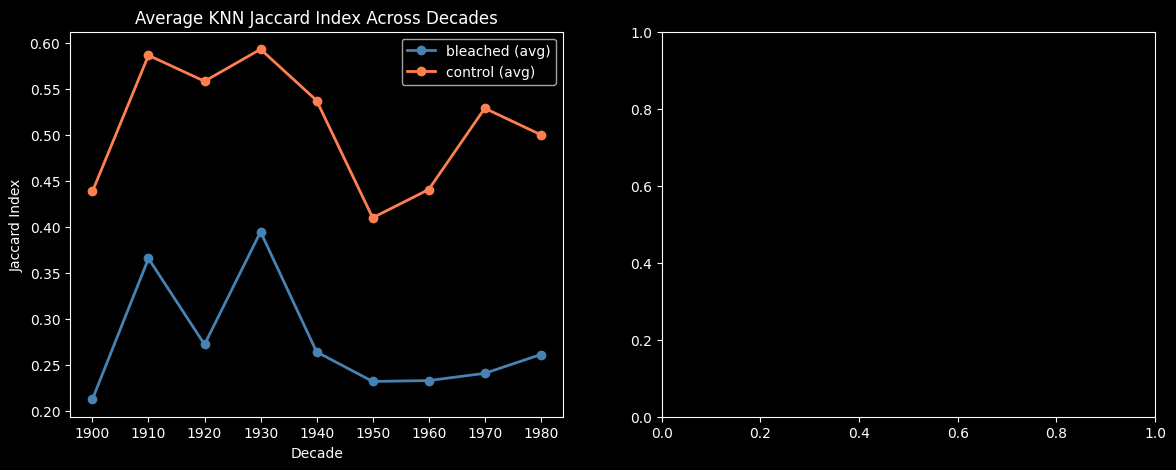

In [ ]:
import numpy as np

decades = list(range(1800, 1990, 10))
plot_start = 10
plot_decades = decades[plot_start:]

bleached_avg = np.mean([bleached_iou[w][plot_start:] for w in bleached], axis=0)
control_avg = np.mean([control_iou[w][plot_start:] for w in control], axis=0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# line plot
ax1.plot(plot_decades, bleached_avg, marker='o', label='bleached (avg)', color='steelblue', linewidth=2)
ax1.plot(plot_decades, control_avg, marker='o', label='control (avg)', color='coral', linewidth=2)
ax1.set_title('Average KNN Jaccard Index Across Decades')
ax1.set_xlabel('Decade')
ax1.set_ylabel('Jaccard Index')
ax1.legend()

# bar chart
averages = [sum(bleached_iou[w])/len(bleached_iou[w]) for w in bleached] + \
           [sum(control_iou[w])/len(control_iou[w]) for w in control]
colors = [bleached_colors[w] for w in bleached] + [control_colors[w] for w in control]
words = bleached + control

ax2.bar(words, averages, color=colors)
ax2.axhline(y=np.mean(averages[:4]), color='steelblue', linestyle='--', label='bleached mean')
ax2.axhline(y=np.mean(averages[4:]), color='coral', linestyle='--', label='control mean')
ax2.set_title('Average Jaccard Index by Word')
ax2.set_xlabel('Word')
ax2.set_ylabel('Average Jaccard Index')
ax2.legend()

plt.tight_layout()
plt.show()

## Conclusion

These findings suggest that Jaccard Index is an effective metric for identifying Sweetser's proposed bleached words in embeddings from 1800-1990. The difference between the bleached set and the control set was roughly 0.1, with copper (control) and go (bleached) showing the highest index values in their respective sets. Go likely reflects post-bleaching stability rather than active change. Sweetser's predicted words held up under this examination. However, unaligned embedding spaces and the small sample size introduces noise that must be considered and diminishes the utility of cosine similarity. Future work could use Procrustes alignment to solve space alignment issues, adding another potentially useful metric into the toolkit. Additionally, a larger word set and more dynamic corpus--such as social media data--could help demonstrate the applicability of these metrics across a variety of domains. The social media dataset could prove a good test for Sweetser's work as many semantic changes may not be as deterministic.